# 📊 Unemployment Analysis with Python
### OIBSIP Internship – Task 2
**Author:** Youssef Hatem Mohamed Bahig  
**Program:** AICTE Oasis Infobyte Internship  

---

## 📌 Objective
Analyze the unemployment rate in India using **2 datasets**:
- `Unemployment in India.csv` — General unemployment data
- `Unemployment_Rate_upto_11_2020.csv` — Detailed state-wise data including Covid-19 period

> **Unemployment Rate** = Number of unemployed people as a percentage of the total labour force.

---
## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('darkgrid')

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---
## Step 2 — Load Both Datasets

In [2]:
# Dataset 1 — General
df1 = pd.read_csv('Unemployment in India.csv')
df1.columns = df1.columns.str.strip()

# Dataset 2 — Detailed (with Covid period)
df2 = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')
df2.columns = df2.columns.str.strip()
df2.columns = ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area', 'longitude', 'latitude']

print('✅ Both datasets loaded!')
print(f'Dataset 1 shape: {df1.shape}')
print(f'Dataset 2 shape: {df2.shape}')

✅ Both datasets loaded!
Dataset 1 shape: (768, 7)
Dataset 2 shape: (267, 9)


---
## Step 3 — Explore Dataset 1

In [3]:
print('📋 Dataset 1 — First 5 rows:')
display(df1.head())

print('\n📋 Columns:', list(df1.columns))
print('\n❓ Missing Values:')
print(df1.isnull().sum())

print('\n📈 Statistics:')
display(df1.describe())

📋 Dataset 1 — First 5 rows:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural



📋 Columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']

❓ Missing Values:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

📈 Statistics:


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


---
## Step 4 — Explore Dataset 2

In [4]:
print('📋 Dataset 2 — First 5 rows:')
display(df2.head())

print('\n📋 Columns:', list(df2.columns))
print('\n❓ Missing Values:')
print(df2.isnull().sum())

print('\n📈 Statistics:')
display(df2.describe())

📋 Dataset 2 — First 5 rows:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74



📋 Columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area', 'longitude', 'latitude']

❓ Missing Values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
longitude                                  0
latitude                                   0
dtype: int64

📈 Statistics:


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


---
## Step 5 — Preprocessing

In [5]:
# Rename columns for easier access
df1.rename(columns={
    'Region'                                  : 'Region',
    'Date'                                    : 'Date',
    'Frequency'                               : 'Frequency',
    'Estimated Unemployment Rate (%)'         : 'Unemployment_Rate',
    'Estimated Employed'                      : 'Employed',
    'Estimated Labour Participation Rate (%)' : 'Labour_Participation_Rate',
    'Area'                                    : 'Area'
}, inplace=True)

df2.rename(columns={
    'Region'                                  : 'Region',
    'Date'                                    : 'Date',
    'Frequency'                               : 'Frequency',
    'Estimated Unemployment Rate (%)'         : 'Unemployment_Rate',
    'Estimated Employed'                      : 'Employed',
    'Estimated Labour Participation Rate (%)' : 'Labour_Participation_Rate',
    'Area'                                    : 'Area'
}, inplace=True)

# Convert dates
df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True)
df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=True)

df1['Month'] = df1['Date'].dt.month
df1['Year']  = df1['Date'].dt.year
df2['Month'] = df2['Date'].dt.month
df2['Year']  = df2['Date'].dt.year

# Covid period label on df2
df2['Period'] = df2['Date'].apply(
    lambda x: 'During Covid-19' if x >= pd.Timestamp('2020-03-01') else 'Before Covid-19'
)

print('✅ Preprocessing done!')
print(f'Date range Dataset 1: {df1["Date"].min().date()} → {df1["Date"].max().date()}')
print(f'Date range Dataset 2: {df2["Date"].min().date()} → {df2["Date"].max().date()}')

✅ Preprocessing done!
Date range Dataset 1: 2019-05-31 → 2020-06-30
Date range Dataset 2: 2020-01-31 → 2020-10-31


---
## Step 6 — Unemployment Rate Over Time (Dataset 1)

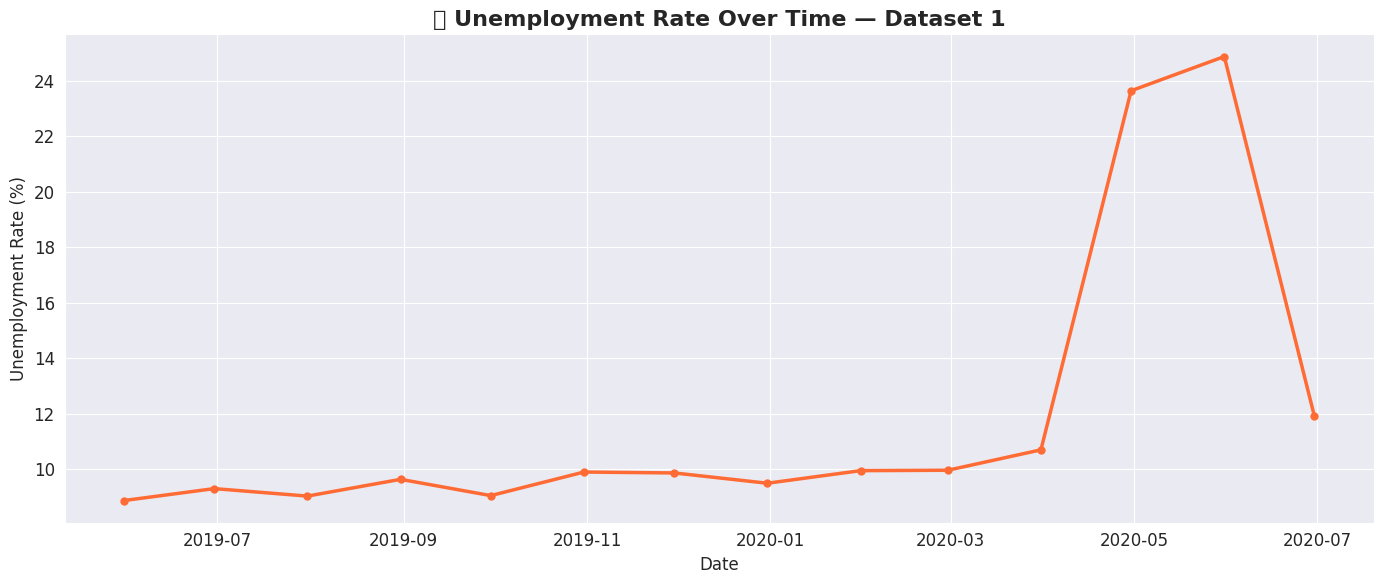

In [6]:
df1_time = df1.groupby('Date')['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(df1_time['Date'], df1_time['Unemployment_Rate'],
         color='#FF6B35', linewidth=2.5, marker='o', markersize=5)
plt.title('📈 Unemployment Rate Over Time — Dataset 1', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

---
## Step 7 — Unemployment Rate Over Time with Covid Highlight (Dataset 2)

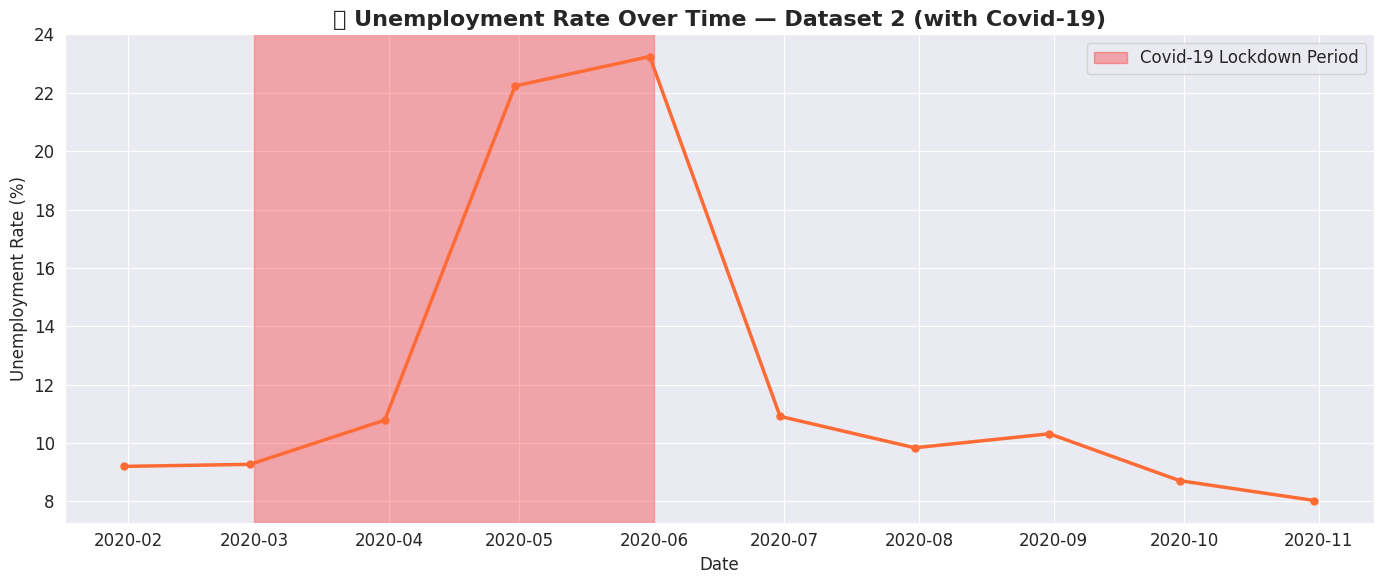

In [7]:
df2_time = df2.groupby('Date')['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(df2_time['Date'], df2_time['Unemployment_Rate'],
         color='#FF6B35', linewidth=2.5, marker='o', markersize=5)

plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-01'),
            alpha=0.3, color='red', label='Covid-19 Lockdown Period')

plt.title('📈 Unemployment Rate Over Time — Dataset 2 (with Covid-19)', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

---
## Step 8 — Unemployment by Region

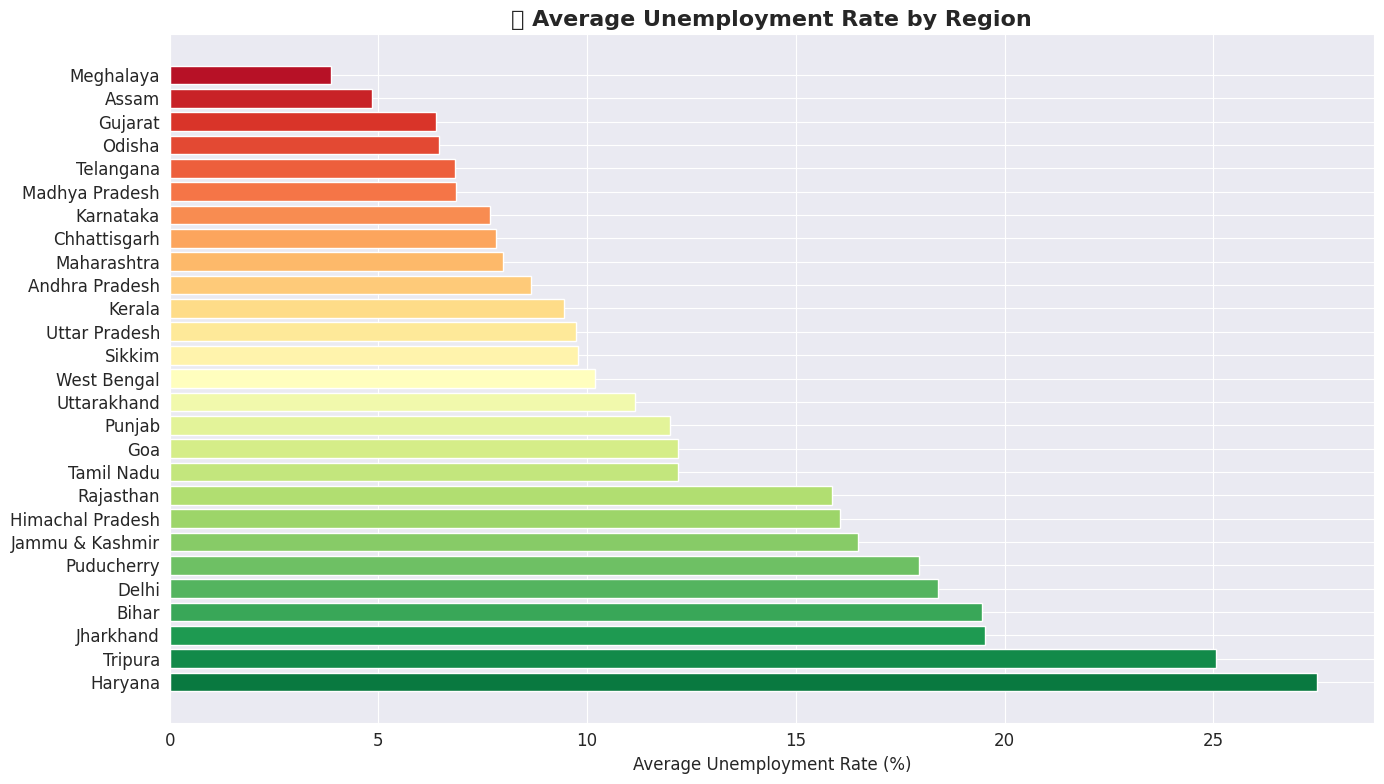

In [8]:
df_region = df2.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 8))
plt.barh(df_region['Region'], df_region['Unemployment_Rate'],
         color=sns.color_palette('RdYlGn_r', len(df_region)))
plt.xlabel('Average Unemployment Rate (%)')
plt.title('🌍 Average Unemployment Rate by Region', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 9 — Rural vs Urban Comparison

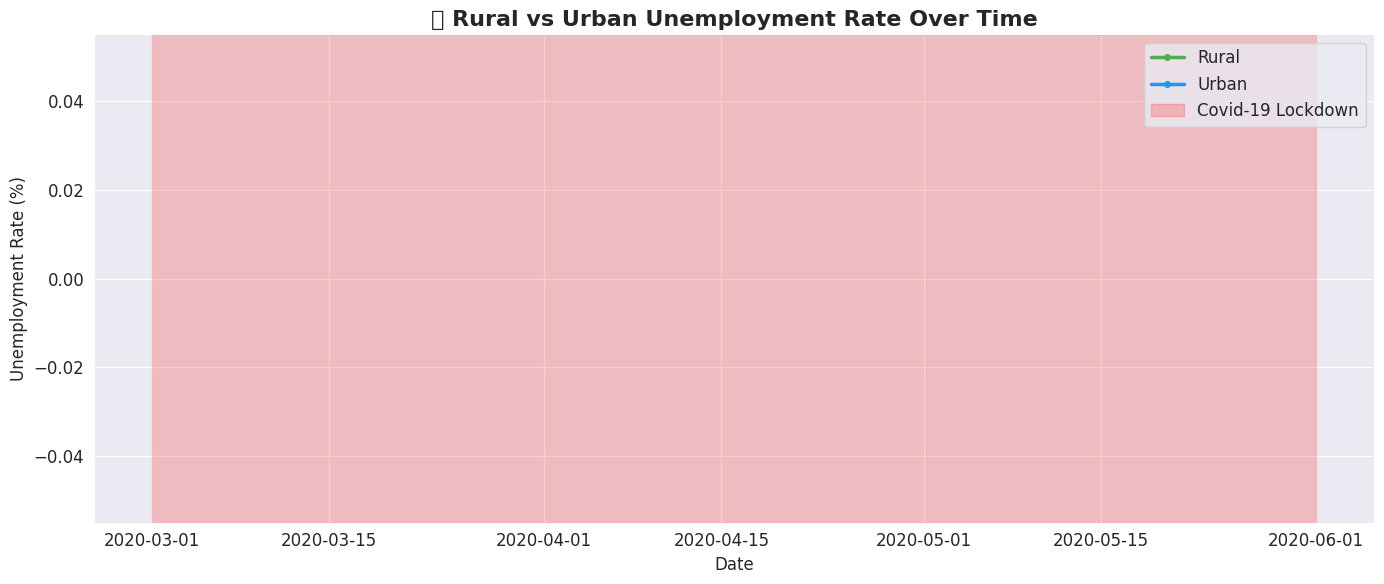

In [9]:
df_area = df2.groupby(['Date', 'Area'])['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(14, 6))
for area, color in zip(['Rural', 'Urban'], ['#4CAF50', '#2196F3']):
    data = df_area[df_area['Area'] == area]
    plt.plot(data['Date'], data['Unemployment_Rate'],
             label=area, color=color, linewidth=2.5, marker='o', markersize=4)

plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-01'),
            alpha=0.2, color='red', label='Covid-19 Lockdown')

plt.title('🏘️ Rural vs Urban Unemployment Rate Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

---
## Step 10 — Covid-19 Impact Analysis

📊 Average Unemployment Rate:
            Period  Unemployment_Rate
0  Before Covid-19           9.231346
1  During Covid-19          12.963860


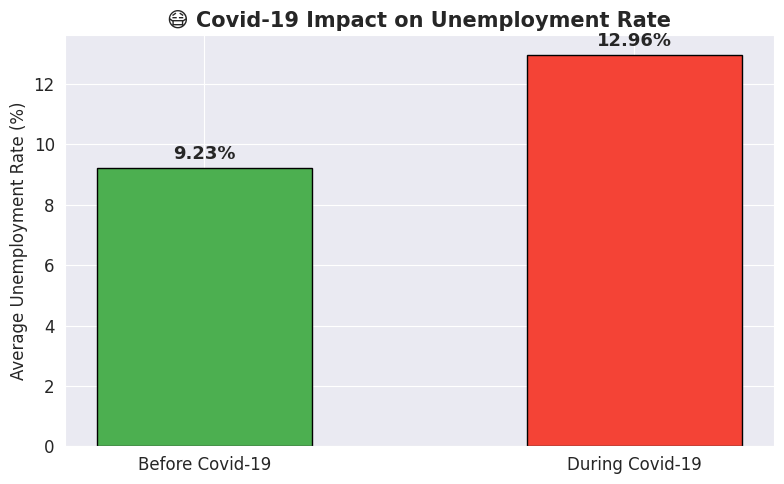

In [10]:
df_covid = df2.groupby('Period')['Unemployment_Rate'].mean().reset_index()
print('📊 Average Unemployment Rate:')
print(df_covid)

plt.figure(figsize=(8, 5))
bars = plt.bar(df_covid['Period'], df_covid['Unemployment_Rate'],
               color=['#4CAF50', '#F44336'], edgecolor='black', width=0.5)

for bar, val in zip(bars, df_covid['Unemployment_Rate']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.2f}%', ha='center', fontweight='bold', fontsize=13)

plt.title('😷 Covid-19 Impact on Unemployment Rate', fontsize=15, fontweight='bold')
plt.ylabel('Average Unemployment Rate (%)')
plt.tight_layout()
plt.show()

---
## Step 11 — Heatmap: Region vs Month

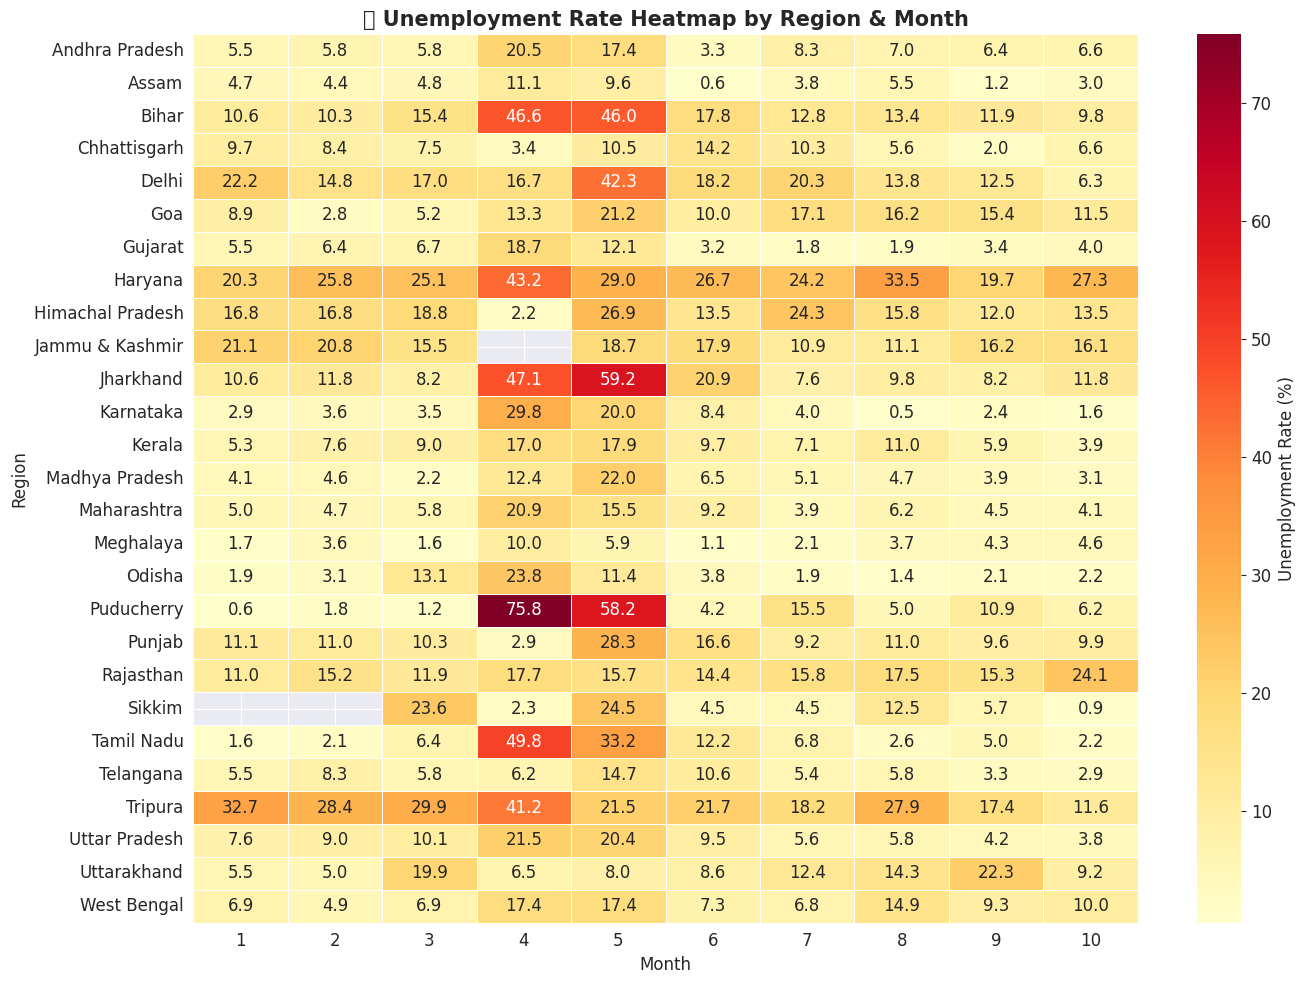

In [11]:
df_pivot = df2.pivot_table(
    values='Unemployment_Rate',
    index='Region',
    columns='Month',
    aggfunc='mean'
)

plt.figure(figsize=(14, 10))
sns.heatmap(df_pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Unemployment Rate (%)'})
plt.title('🗺️ Unemployment Rate Heatmap by Region & Month', fontsize=15, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

---
## Step 12 — Top 5 Most & Least Affected Regions

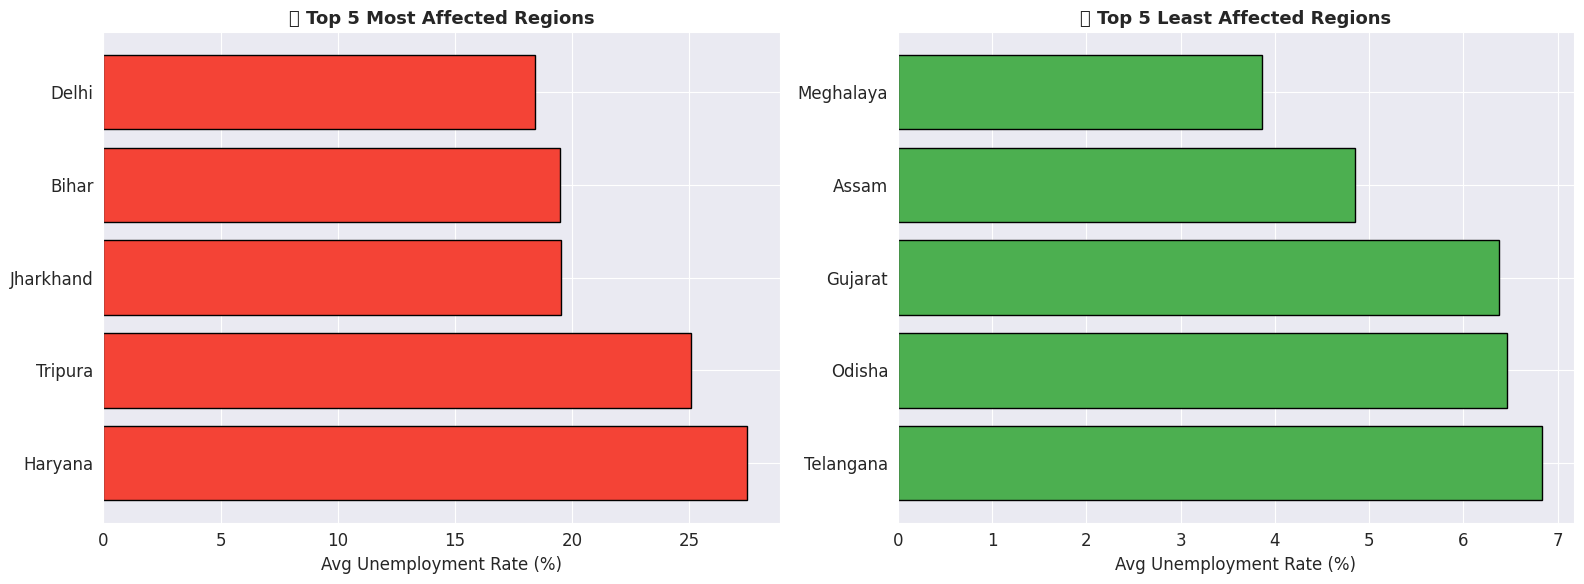


🔴 Most Affected:
Region
Haryana      27.477
Tripura      25.055
Jharkhand    19.539
Bihar        19.471
Delhi        18.414
Name: Unemployment_Rate, dtype: float64

🟢 Least Affected:
Region
Telangana    6.833
Odisha       6.462
Gujarat      6.376
Assam        4.856
Meghalaya    3.866
Name: Unemployment_Rate, dtype: float64


In [ ]:
df_region_avg = df2.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False)

top5    = df_region_avg.head(5)
bottom5 = df_region_avg.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top5.index, top5.values, color='#F44336', edgecolor='black')
axes[0].set_title('🔴 Top 5 Most Affected Regions', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Avg Unemployment Rate (%)')
axes[1].barh(bottom5.index, bottom5.values, color='#4CAF50', edgecolor='black')
axes[1].set_title('🟢 Top 5 Least Affected Regions', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg Unemployment Rate (%)')

plt.tight_layout()
plt.show()

print('\n🔴 Most Affected:')
print(top5)
print('\n🟢 Least Affected:')
print(bottom5)

---
## Step 13 — Correlation Analysis

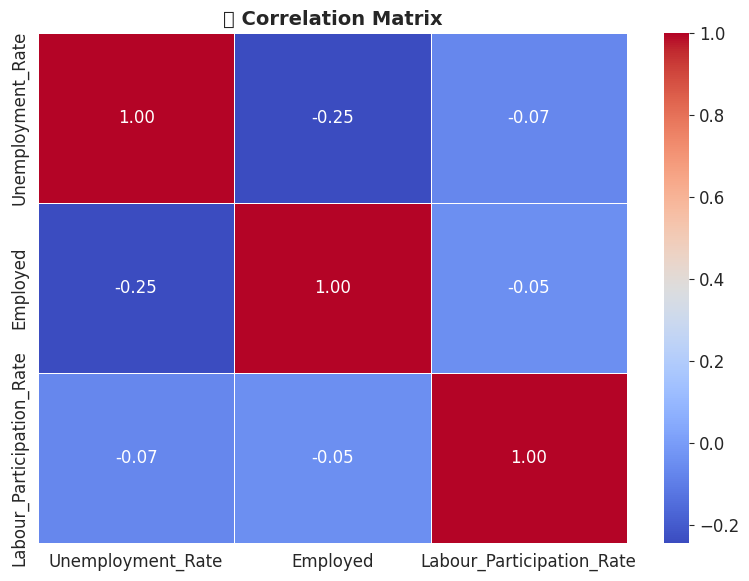

In [13]:
plt.figure(figsize=(8, 6))
corr = df2[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('🔗 Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 14 — Final Summary & Key Insights

In [14]:
print('=' * 60)
print('       UNEMPLOYMENT ANALYSIS — KEY INSIGHTS')
print('=' * 60)
print(f"""
📌 Dataset 1 — Overall Average : {df1['Unemployment_Rate'].mean():.2f}%
📌 Dataset 2 — Overall Average : {df2['Unemployment_Rate'].mean():.2f}%

📌 Max Unemployment Rate       : {df2['Unemployment_Rate'].max():.2f}%
📌 Min Unemployment Rate       : {df2['Unemployment_Rate'].min():.2f}%

😷 Before Covid-19 Average     : {df2[df2['Period']=='Before Covid-19']['Unemployment_Rate'].mean():.2f}%
😷 During Covid-19 Average     : {df2[df2['Period']=='During Covid-19']['Unemployment_Rate'].mean():.2f}%

🔴 Most  Affected Region       : {df_region_avg.index[0]}  ({df_region_avg.iloc[0]:.2f}%)
🟢 Least Affected Region       : {df_region_avg.index[-1]} ({df_region_avg.iloc[-1]:.2f}%)
""")


       UNEMPLOYMENT ANALYSIS — KEY INSIGHTS

📌 Dataset 1 — Overall Average : 11.79%
📌 Dataset 2 — Overall Average : 12.24%

📌 Max Unemployment Rate       : 75.85%
📌 Min Unemployment Rate       : 0.50%

😷 Before Covid-19 Average     : 9.23%
😷 During Covid-19 Average     : 12.96%

🔴 Most  Affected Region       : Haryana  (27.48%)
🟢 Least Affected Region       : Meghalaya (3.87%)

